# Data Cleaning & EDA
**DSC Machine Learning Study Group — Meet 2**

Dataset: Telco Customer Churn (7.043 pelanggan, 21 fitur)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)
sns.set_palette("husl")
np.random.seed(42)

---
# PART 1: DATA CLEANING

## 1. First Look

In [2]:
df_raw = pd.read_csv("data/telco-customer-churn.csv")
print(f"Shape: {df_raw.shape}")
display(df_raw.head())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
display(df_raw.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observasi:**
- `TotalCharges` bertipe `object` — seharusnya numerik. Red flag.
- `SeniorCitizen` pakai `0/1`, kolom binary lain pakai `Yes/No`. Inkonsisten.

## 2. Missing Values

In [5]:
missing_standard = df_raw.isnull().sum()
print(f"Total NaN: {missing_standard.sum()} — suspicious, cek disguised missing.")

Total NaN: 0 — suspicious, cek disguised missing.


### Disguised Missing — TotalCharges
Tidak semua missing tampil sebagai `NaN`. Bisa berupa spasi `" "`, `0`, `-1`, `"?"`.

In [6]:
tc_numeric = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
disguised_mask = tc_numeric.isna() & df_raw["TotalCharges"].notna()

print(f"Disguised missing di TotalCharges: {disguised_mask.sum()}")
print(f"Nilai asli: {df_raw.loc[disguised_mask, 'TotalCharges'].values}")
display(
    df_raw.loc[
        disguised_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

Disguised missing di TotalCharges: 11
Nilai asli: [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Interpretasi:** Semua punya `tenure = 0` — pelanggan baru, belum pernah ditagih.
Ini **MAR** (Missing At Random) — missing-nya tergantung variabel lain (`tenure`).

| Mekanisme | Definisi | Contoh |
|-----------|---------|--------|
| **MCAR** | $P(R=0) = \text{const}$ | Sensor rusak random |
| **MAR** | $P(R=0 \mid Y_{obs})$ | TotalCharges kosong karena tenure=0 |
| **MNAR** | $P(R=0 \mid Y_{mis})$ | Orang kaya tolak isi survei gaji |

In [7]:
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
print(
    f"TotalCharges dtype: {df['TotalCharges'].dtype}, missing: {df['TotalCharges'].isna().sum()}"
)

TotalCharges dtype: float64, missing: 0


### Visualisasi Missing (demo sintetis)

In [8]:
df_demo = df.copy()
n = len(df_demo)

df_demo.loc[np.random.rand(n) < 0.05, "MonthlyCharges"] = np.nan  # MCAR
df_demo.loc[df_demo["InternetService"] == "No", "OnlineSecurity"] = np.nan  # MAR
df_demo.loc[(df["tenure"] < 6) & (np.random.rand(n) < 0.4), "tenure"] = np.nan  # MNAR

missing_demo = df_demo.isnull().sum()
display(missing_demo[missing_demo > 0])

tenure             550
OnlineSecurity    1526
MonthlyCharges     339
dtype: int64

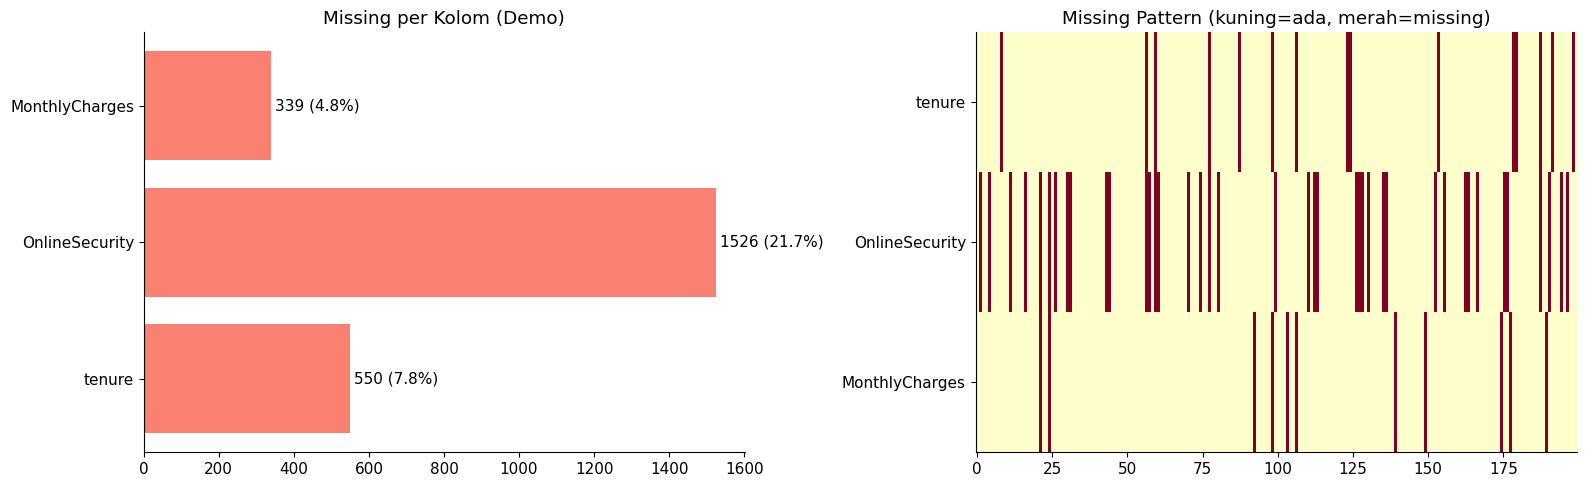

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cols_miss = missing_demo[missing_demo > 0]
axes[0].barh(cols_miss.index, cols_miss.values, color="salmon")
for i, v in enumerate(cols_miss.values):
    axes[0].text(v + 10, i, f"{v} ({v / n:.1%})", va="center")
axes[0].set_title("Missing per Kolom (Demo)")

sample_idx = np.random.choice(n, 200, replace=False)
axes[1].imshow(
    df_demo.loc[sample_idx, cols_miss.index].isnull().values.T,
    aspect="auto",
    cmap="YlOrRd",
)
axes[1].set_yticks(range(len(cols_miss)))
axes[1].set_yticklabels(cols_miss.index)
axes[1].set_title("Missing Pattern (kuning=ada, merah=missing)")

plt.tight_layout()
plt.savefig("figures/nb_missing_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

### Perbandingan Imputasi

| Metode | Formula | Trade-off |
|--------|---------|-----------|
| Mean | $\hat{x} = \bar{x}$ | Mengurangi variance |
| Median | $\hat{x} = Q_2$ | Robust terhadap outlier |
| KNN | Rata-rata $k$ neighbors | Preserves local structure, lambat |

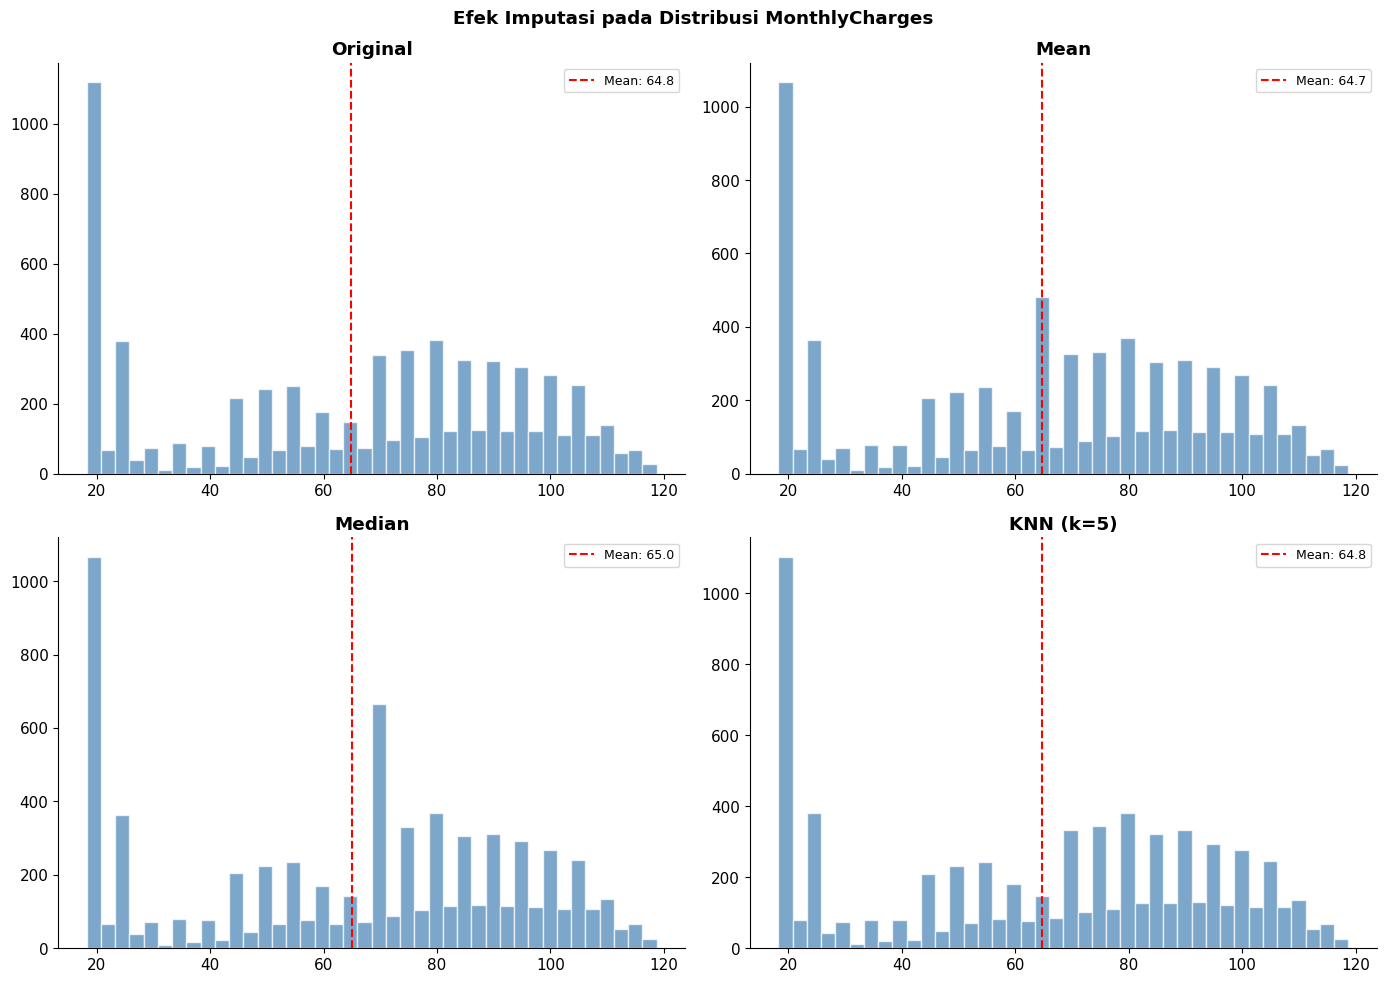

In [10]:
from sklearn.impute import KNNImputer

monthly_nan = df_demo["MonthlyCharges"].copy()
strategies = {
    "Original": df["MonthlyCharges"].values,
    "Mean": monthly_nan.fillna(monthly_nan.mean()),
    "Median": monthly_nan.fillna(monthly_nan.median()),
}

knn_data = df_demo[["MonthlyCharges", "tenure", "TotalCharges"]].copy()
knn_data["tenure"] = knn_data["tenure"].fillna(knn_data["tenure"].median())
strategies["KNN (k=5)"] = KNNImputer(n_neighbors=5).fit_transform(knn_data)[:, 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, data) in zip(axes.ravel(), strategies.items()):
    ax.hist(data, bins=40, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(
        np.nanmean(data), color="red", ls="--", label=f"Mean: {np.nanmean(data):.1f}"
    )
    ax.set_title(name, fontweight="bold")
    ax.legend(fontsize=9)
plt.suptitle("Efek Imputasi pada Distribusi MonthlyCharges", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/nb_imputation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** Mean imputation mengurangi variance (distribusi "lancip" di tengah).
KNN mempertahankan bentuk distribusi lebih baik.

## 3. Duplikat

In [11]:
print(f"Duplikat (semua kolom): {df.duplicated().sum()}")
print(f"Duplikat (tanpa ID): {df.drop(columns='customerID').duplicated().sum()}")

Duplikat (semua kolom): 0
Duplikat (tanpa ID): 22


## 4. Data Type Issues

In [12]:
print(
    f"SeniorCitizen: {df['SeniorCitizen'].unique()} — 0/1, bukan Yes/No seperti kolom lain"
)
print(f"Persentase senior: {df['SeniorCitizen'].mean():.1%}")

SeniorCitizen: [0 1] — 0/1, bukan Yes/No seperti kolom lain
Persentase senior: 16.2%


In [13]:
three_level = [
    c for c in df.columns if df[c].nunique() == 3 and df[c].dtype == "object"
]
print(f"Kolom 3-level: {three_level}")
display(df["OnlineSecurity"].value_counts())

Kolom 3-level: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

**Interpretasi:** `No` vs `No internet service` itu berbeda secara domain.
Keputusan encoding ditunda ke meet selanjutnya.

## 5. Outlier Detection

$$IQR = Q_3 - Q_1, \quad \text{Fence} = [Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$$
$$z_i = \frac{x_i - \bar{x}}{s}, \quad M_i = \frac{0.6745(x_i - \tilde{x})}{MAD}$$

In [14]:
numeric_cols = df.select_dtypes(include="number").columns.drop("SeniorCitizen")


def detect_iqr(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - k * iqr) | (s > q3 + k * iqr)).sum()


def detect_zscore(s, t=3):
    return (np.abs(stats.zscore(s.dropna())) > t).sum()


def detect_mad(s, t=3.5):
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0:
        return 0
    return (np.abs(0.6745 * (s - med) / mad) > t).sum()


comparison = pd.DataFrame(
    {
        "IQR": {c: detect_iqr(df[c]) for c in numeric_cols},
        "Z-score": {c: detect_zscore(df[c]) for c in numeric_cols},
        "MAD": {c: detect_mad(df[c]) for c in numeric_cols},
    }
)
display(comparison)

,IQR,Z-score,MAD
tenure,0,0,0
MonthlyCharges,0,0,0
TotalCharges,0,0,136


**Interpretasi:** IQR paling sensitif, Z-score paling konservatif. MAD lebih robust karena median-based.

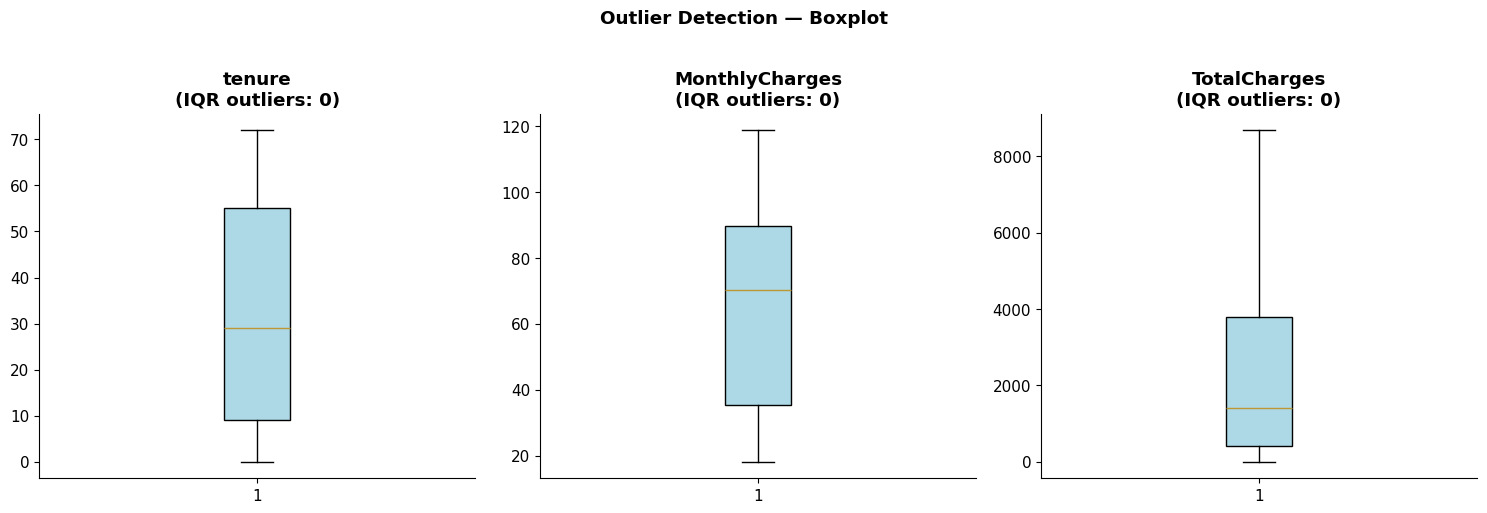

In [15]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(
        df[col].dropna(), patch_artist=True, boxprops=dict(facecolor="lightblue")
    )
    ax.set_title(f"{col}\n(IQR outliers: {detect_iqr(df[col])})", fontweight="bold")
plt.suptitle("Outlier Detection — Boxplot", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/nb_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Transformasi: Log
$$y = \ln(1 + x)$$

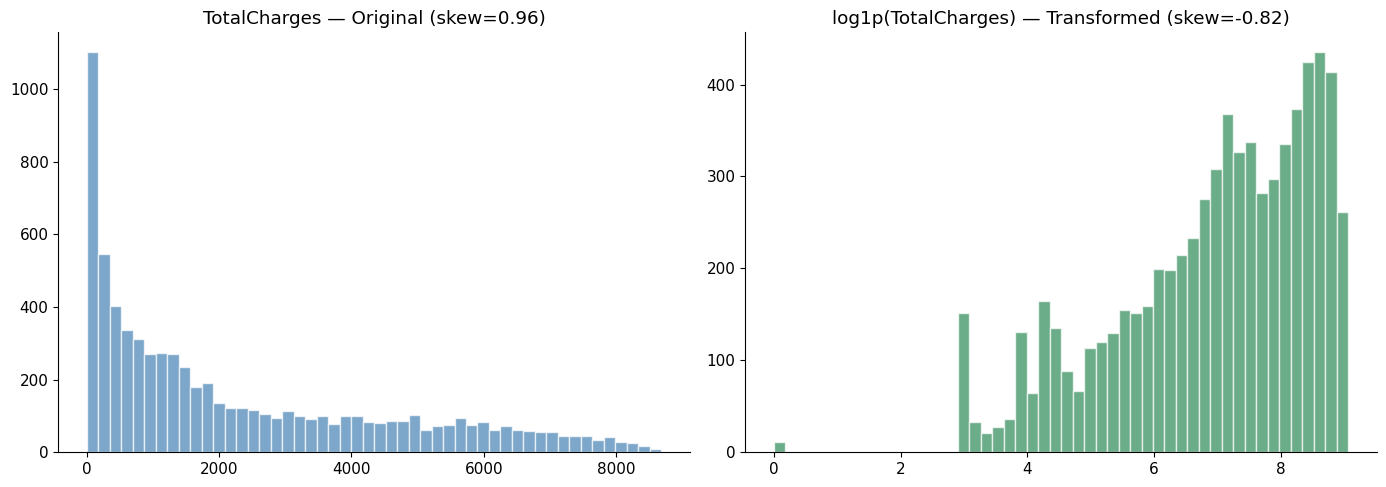

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(
    df["TotalCharges"], bins=50, alpha=0.7, color="steelblue", edgecolor="white"
)
axes[0].set_title(f"TotalCharges — Original (skew={df['TotalCharges'].skew():.2f})")

log_tc = np.log1p(df["TotalCharges"])
axes[1].hist(log_tc, bins=50, alpha=0.7, color="seagreen", edgecolor="white")
axes[1].set_title(f"log1p(TotalCharges) — Transformed (skew={log_tc.skew():.2f})")
plt.tight_layout()
plt.savefig("figures/nb_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

---
# PART 2: EXPLORATORY DATA ANALYSIS

## 6. Anscombe's Quartet
Empat dataset, statistik **identik**, pattern **berbeda**. Selalu plot dulu.

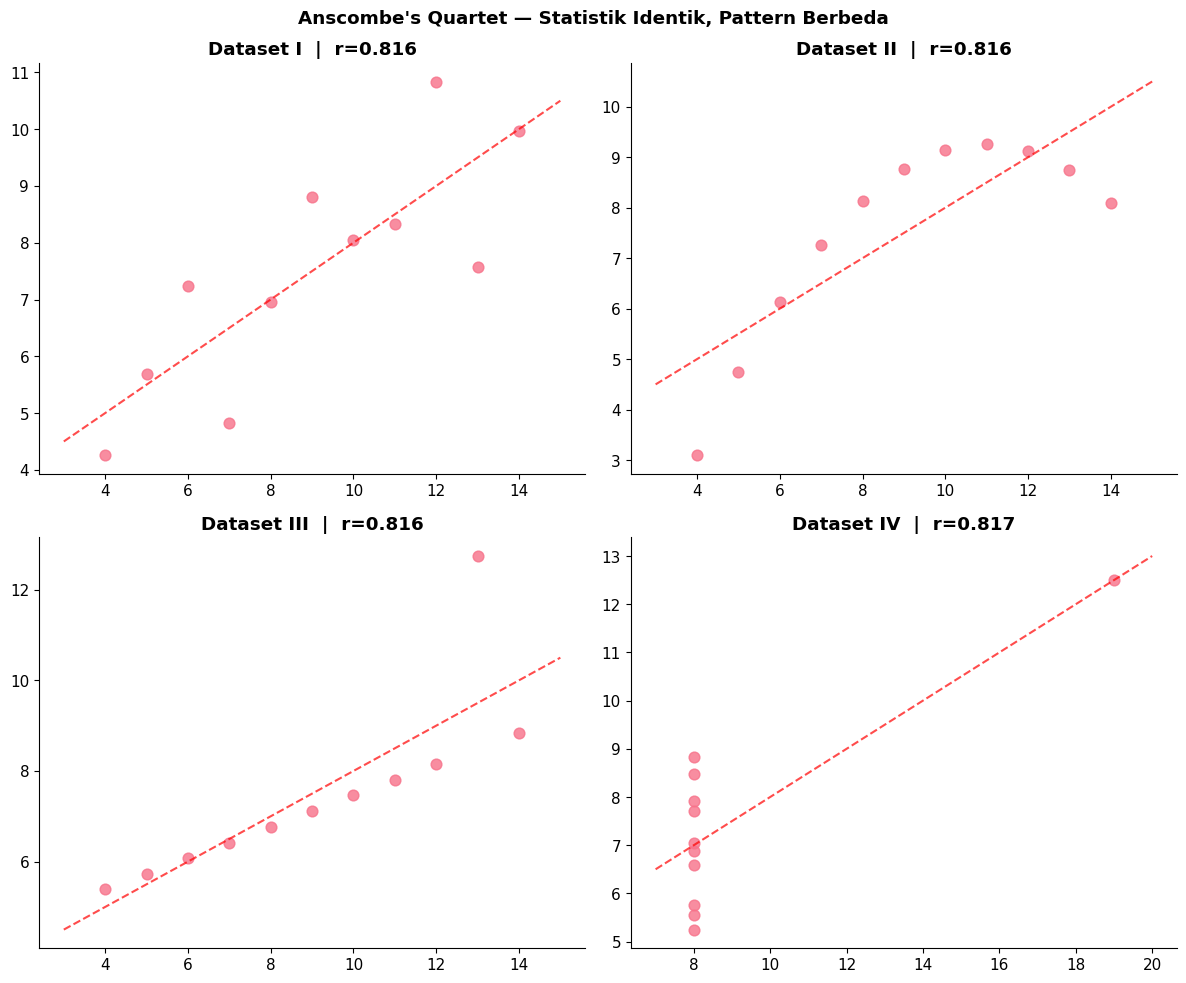

In [17]:
anscombe = sns.load_dataset("anscombe")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, ds in zip(axes.ravel(), ["I", "II", "III", "IV"]):
    sub = anscombe[anscombe["dataset"] == ds]
    ax.scatter(sub["x"], sub["y"], s=60, alpha=0.8)
    slope, intercept = np.polyfit(sub["x"], sub["y"], 1)
    x_line = np.linspace(sub["x"].min() - 1, sub["x"].max() + 1, 100)
    ax.plot(x_line, slope * x_line + intercept, "r--", alpha=0.7)
    ax.set_title(f"Dataset {ds}  |  r={sub['x'].corr(sub['y']):.3f}", fontweight="bold")
plt.suptitle(
    "Anscombe's Quartet — Statistik Identik, Pattern Berbeda", fontweight="bold"
)
plt.tight_layout()
plt.savefig("figures/nb_anscombe_demo.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Statistik Deskriptif

$$g_1 = \frac{m_3}{m_2^{3/2}} \quad \text{(skewness)}, \qquad g_2 = \frac{m_4}{m_2^2} - 3 \quad \text{(excess kurtosis)}$$

In [18]:
desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurtosis()
display(desc)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,0.239540,-1.387372
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,-0.220524,-1.257260
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,0.963235,-0.228580


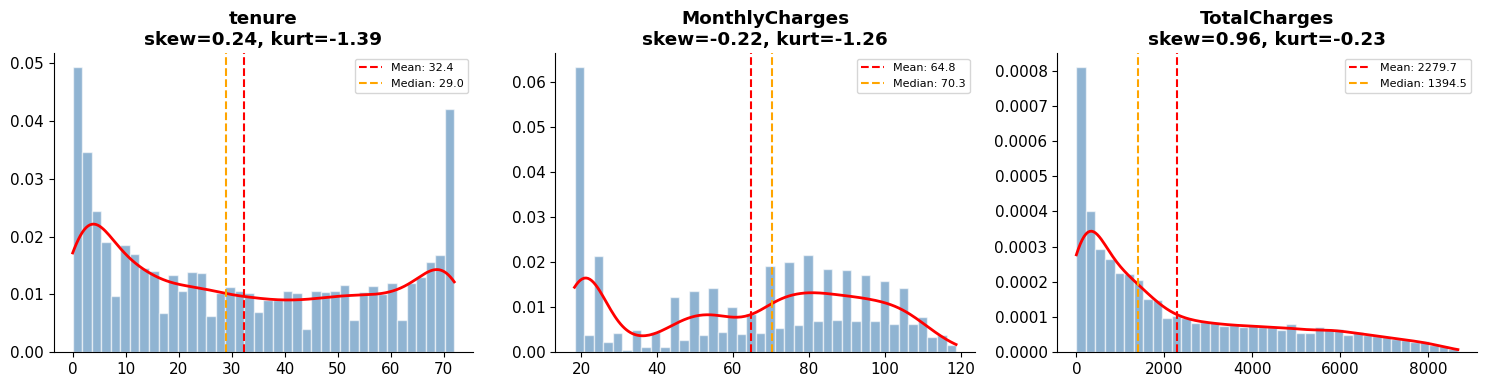

In [19]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    data = df[col].dropna()
    ax.hist(
        data, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="white"
    )
    if data.std() > 0:
        kde = stats.gaussian_kde(data)
        x_r = np.linspace(data.min(), data.max(), 200)
        ax.plot(x_r, kde(x_r), "r-", lw=2)
    ax.axvline(data.mean(), color="red", ls="--", label=f"Mean: {data.mean():.1f}")
    ax.axvline(
        data.median(), color="orange", ls="--", label=f"Median: {data.median():.1f}"
    )
    ax.set_title(
        f"{col}\nskew={data.skew():.2f}, kurt={data.kurtosis():.2f}", fontweight="bold"
    )
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/nb_skew_kurt.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:**
- `tenure`: Bimodal — banyak pelanggan baru (0-5 bln) dan lama (70+ bln)
- `TotalCharges`: Right-skewed kuat — wajar, $\approx$ tenure × MonthlyCharges
- `MonthlyCharges`: Relatif merata

## 8. Univariate — Categorical

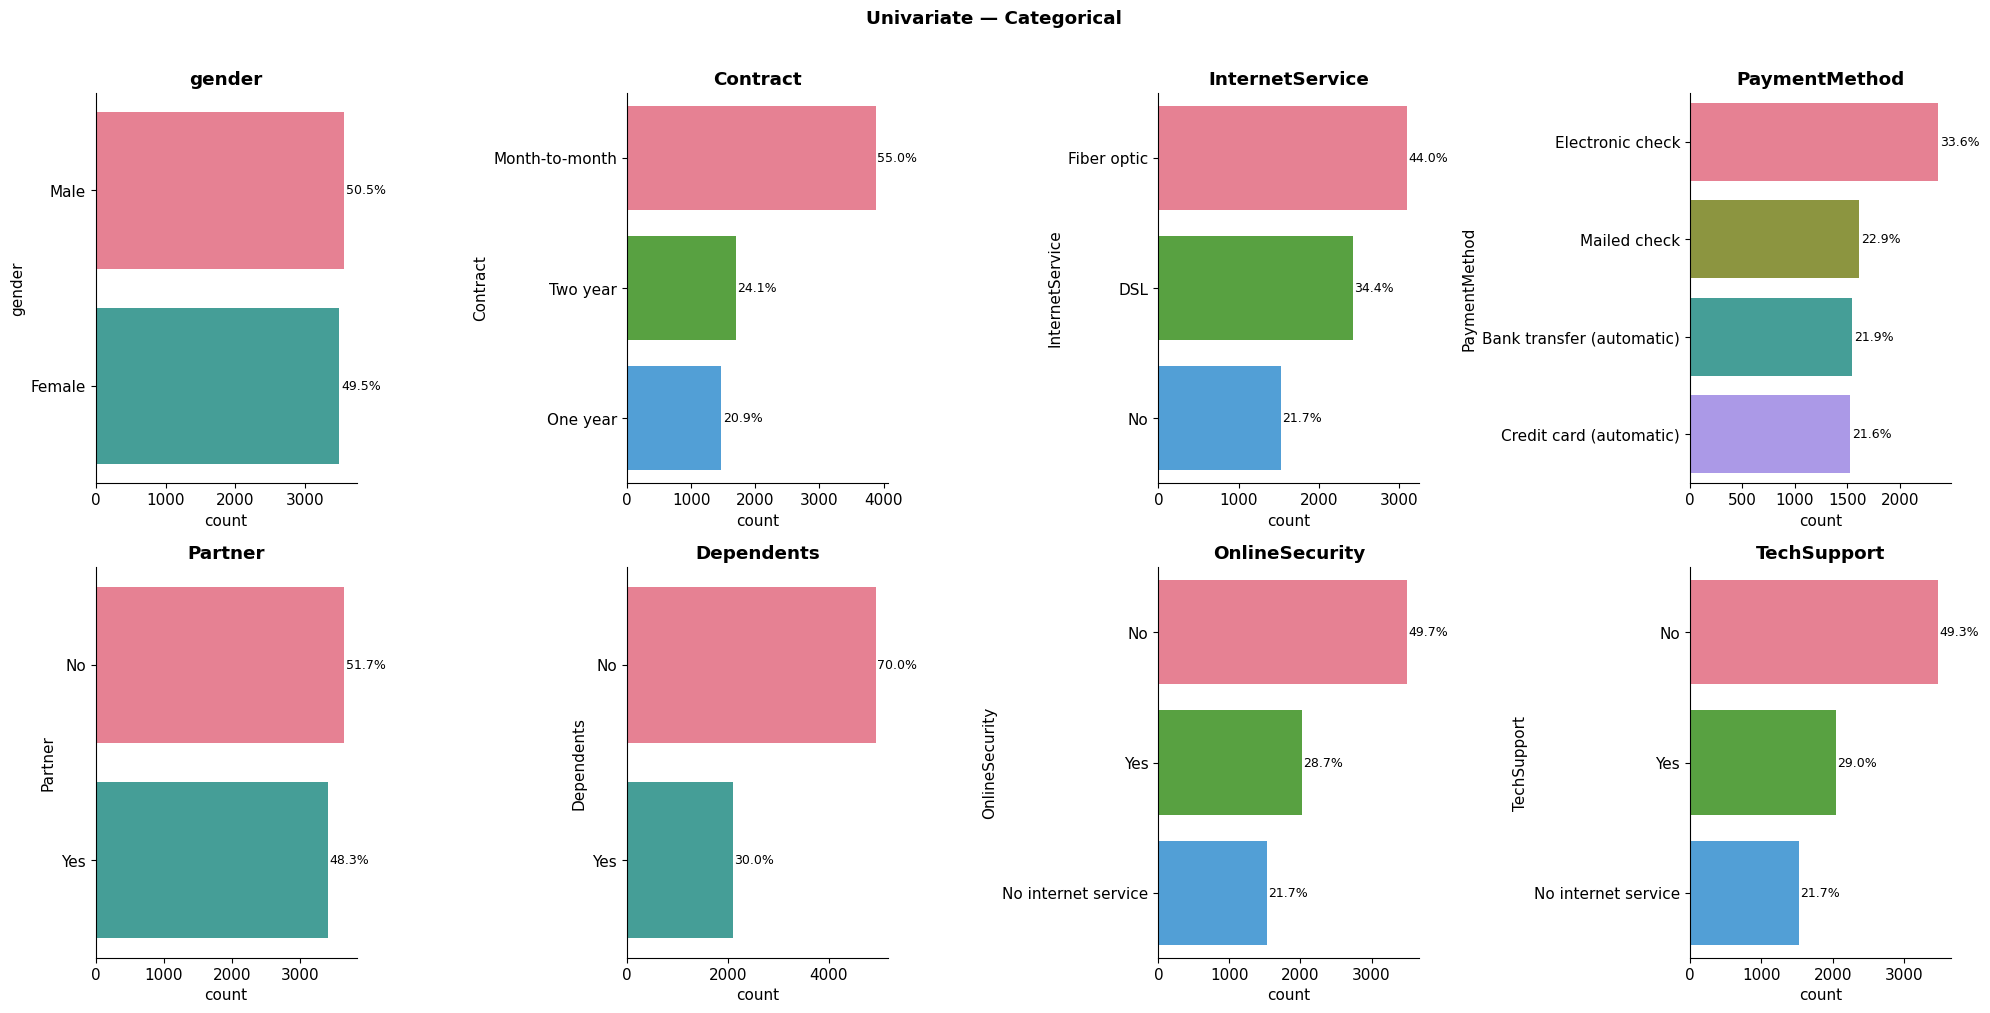

In [20]:
key_cats = [
    "gender",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "Partner",
    "Dependents",
    "OnlineSecurity",
    "TechSupport",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), key_cats):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette="husl")
    ax.set_title(col, fontweight="bold")
    total = len(df)
    for p in ax.patches:
        w = p.get_width()
        ax.text(
            w + 20,
            p.get_y() + p.get_height() / 2,
            f"{w / total:.1%}",
            va="center",
            fontsize=9,
        )
plt.suptitle("Univariate — Categorical", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/nb_univariate_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Bivariate Analysis

### Numerical vs Numerical

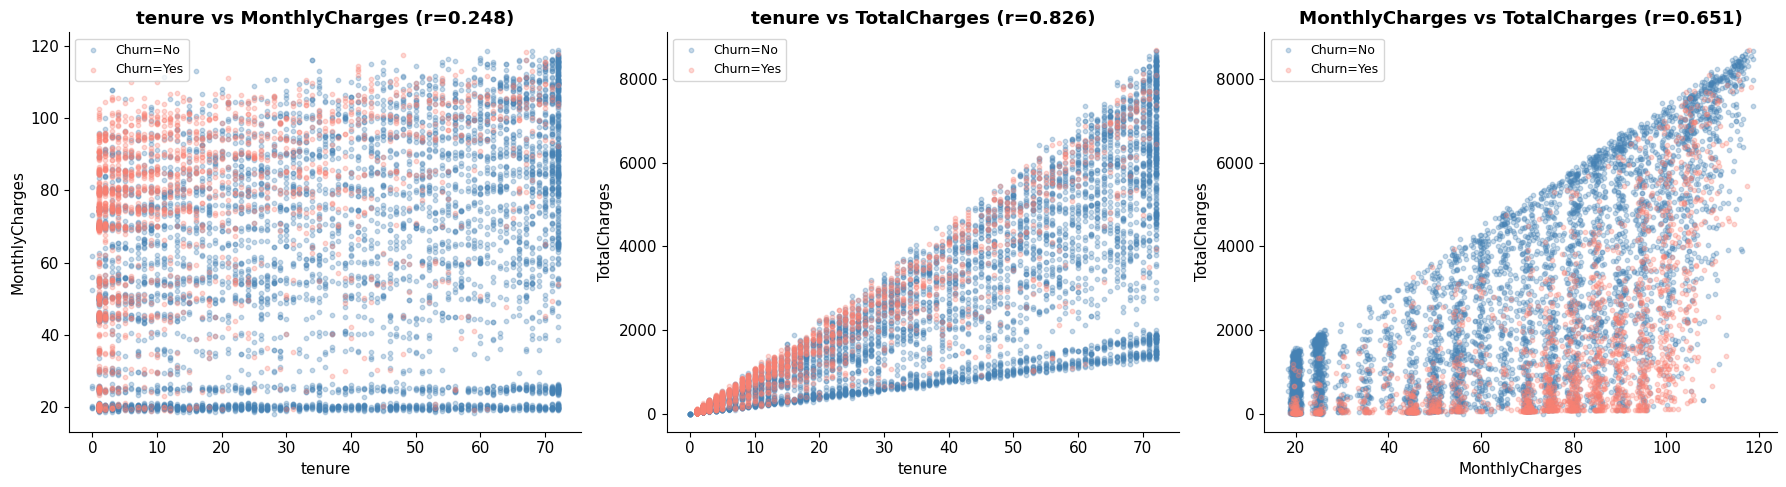

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ("tenure", "MonthlyCharges"),
    ("tenure", "TotalCharges"),
    ("MonthlyCharges", "TotalCharges"),
]
for ax, (x, y) in zip(axes, pairs):
    for label, color in [("No", "steelblue"), ("Yes", "salmon")]:
        m = df["Churn"] == label
        ax.scatter(
            df.loc[m, x],
            df.loc[m, y],
            alpha=0.3,
            s=10,
            label=f"Churn={label}",
            color=color,
        )
    r = df[x].corr(df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} (r={r:.3f})", fontweight="bold")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/nb_bivariate_num_num.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** Churn (merah) terkonsentrasi di tenure rendah — pelanggan baru lebih rentan.

### Categorical vs Numerical

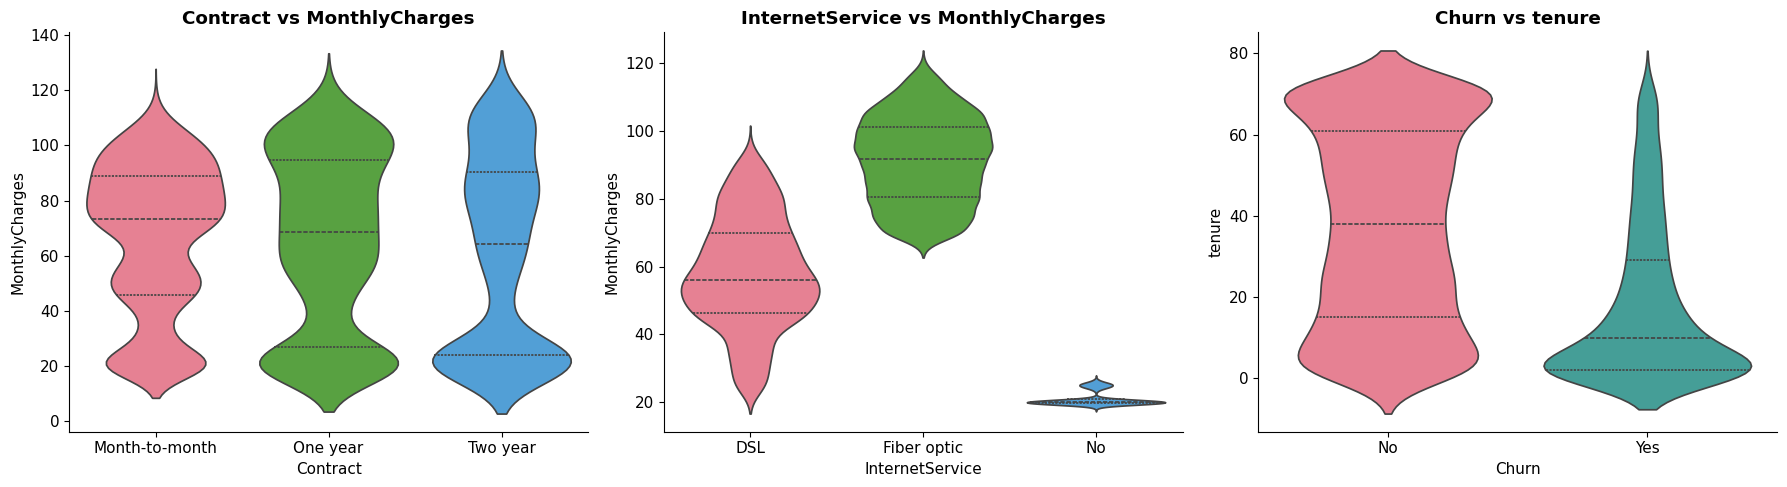

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cat, num) in zip(
    axes,
    [
        ("Contract", "MonthlyCharges"),
        ("InternetService", "MonthlyCharges"),
        ("Churn", "tenure"),
    ],
):
    sns.violinplot(data=df, x=cat, y=num, ax=ax, palette="husl", inner="quartile")
    ax.set_title(f"{cat} vs {num}", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/nb_bivariate_cat_num.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** Pelanggan churn punya tenure jauh lebih pendek (median ~10 vs ~38 bulan).

### Cramér's V — Categorical vs Categorical

$$V = \sqrt{\frac{\chi^2 / n}{\min(r-1, c-1)}}$$

In [23]:
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include="object").columns.drop("customerID")


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))


scores = {col: cramers_v(df[col], df["Churn"]) for col in cat_cols.drop("Churn")}
for col, v in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {col:<20} {v:.3f} {'█' * int(v * 50)}")

  Contract             0.410 ████████████████████
  OnlineSecurity       0.347 █████████████████
  TechSupport          0.343 █████████████████
  InternetService      0.322 ████████████████
  PaymentMethod        0.303 ███████████████
  OnlineBackup         0.292 ██████████████
  DeviceProtection     0.282 ██████████████
  StreamingMovies      0.231 ███████████
  StreamingTV          0.231 ███████████
  PaperlessBilling     0.191 █████████
  Dependents           0.164 ████████
  Partner              0.150 ███████
  MultipleLines        0.040 ██
  PhoneService         0.011 
  gender               0.008 


**Interpretasi:** `Contract` asosiasi terkuat dengan `Churn`. Month-to-month paling rentan.

### Pearson vs Spearman

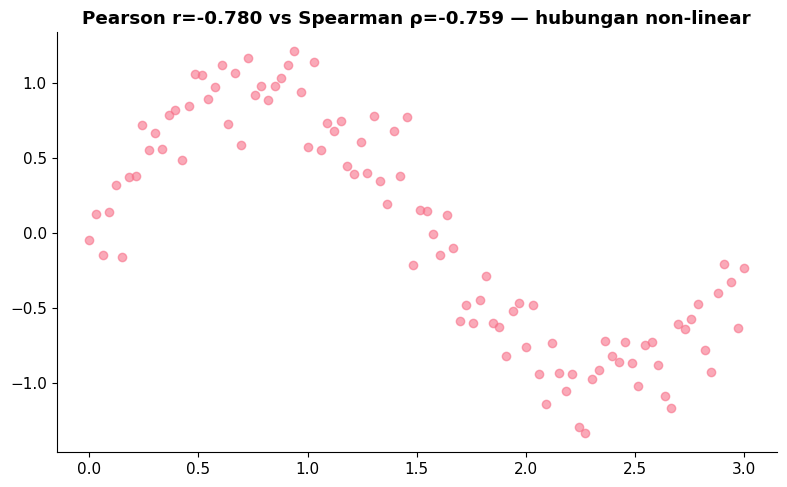

In [24]:
x_demo = np.linspace(0, 3, 100)
y_demo = np.sin(2 * x_demo) + np.random.normal(0, 0.2, 100)
r_p, _ = stats.pearsonr(x_demo, y_demo)
r_s, _ = stats.spearmanr(x_demo, y_demo)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_demo, y_demo, alpha=0.6)
ax.set_title(
    f"Pearson r={r_p:.3f} vs Spearman ρ={r_s:.3f} — hubungan non-linear",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("figures/nb_pearson_vs_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** Pearson hanya ukur hubungan **linear**. Korelasi 0 ≠ tidak ada hubungan.

## 10. Multivariate — Correlation Heatmap

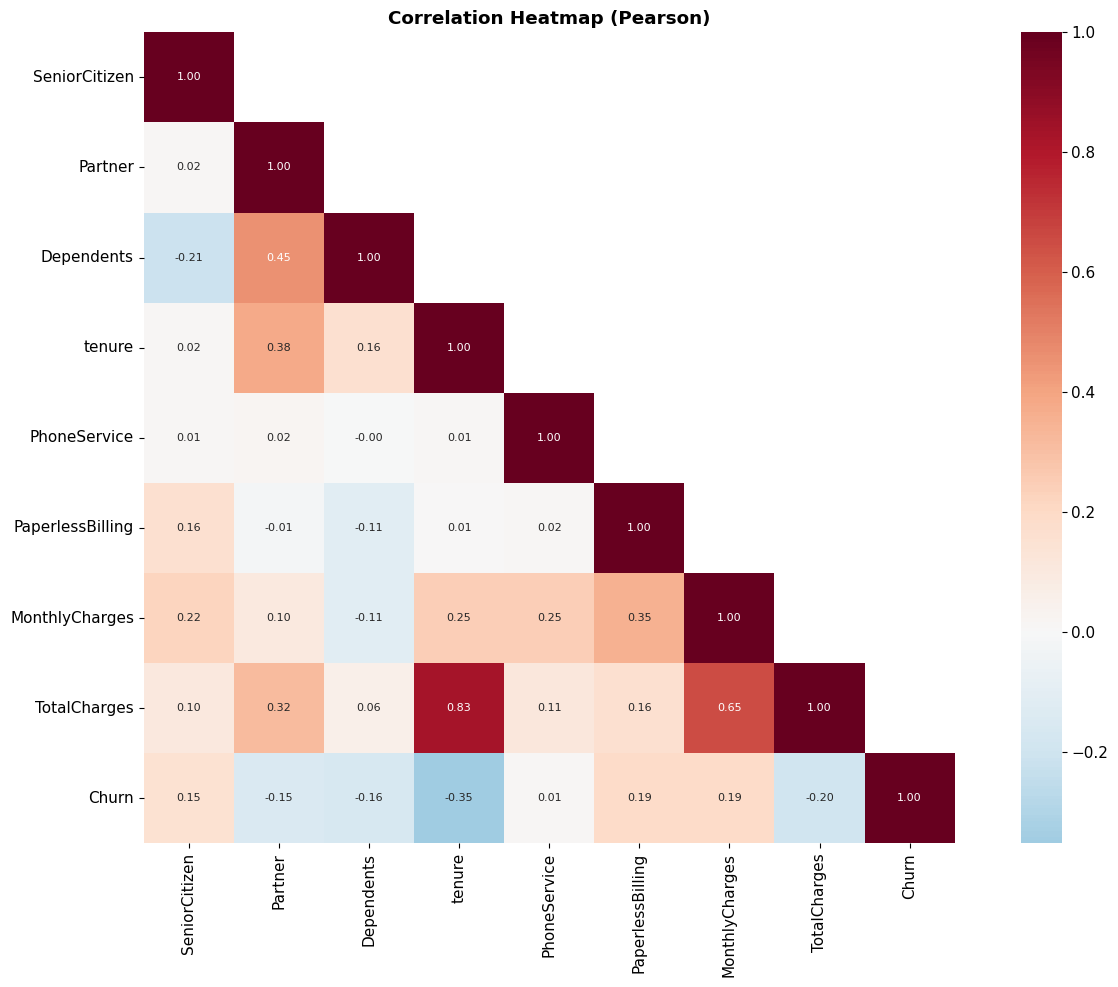

In [25]:
df_enc = df.copy()
binary_map = {"Yes": 1, "No": 0}
for col in df_enc.select_dtypes(include="object").columns:
    if set(df_enc[col].unique()) <= {"Yes", "No"}:
        df_enc[col] = df_enc[col].map(binary_map)

num_bin = df_enc.select_dtypes(include="number").columns.drop(
    "customerID", errors="ignore"
)
corr = df_enc[num_bin].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Correlation Heatmap (Pearson)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/nb_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

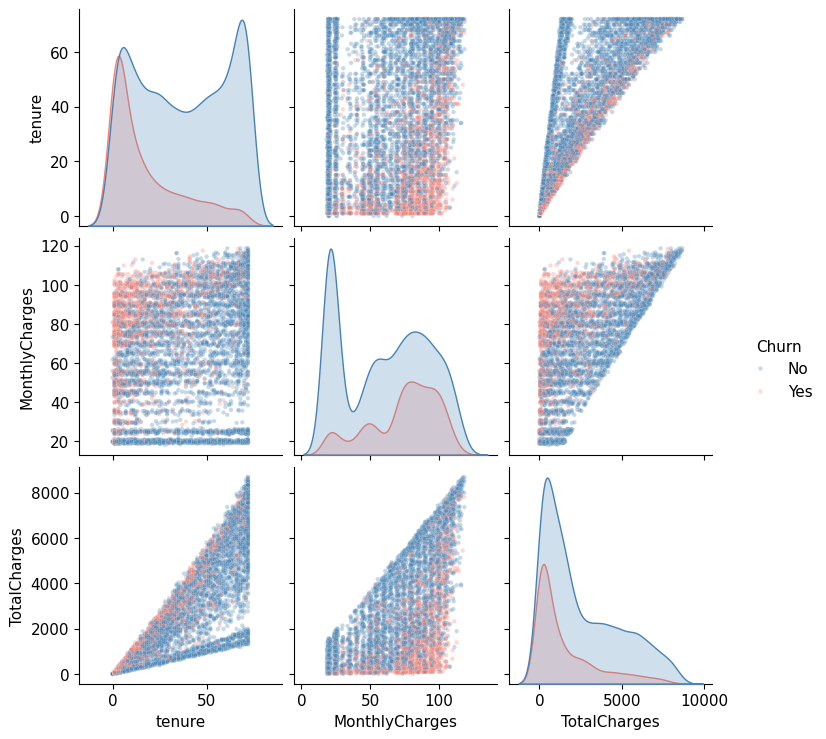

In [26]:
g = sns.pairplot(
    df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]],
    hue="Churn",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    palette={"No": "steelblue", "Yes": "salmon"},
)
plt.savefig("figures/nb_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Target Variable Analysis

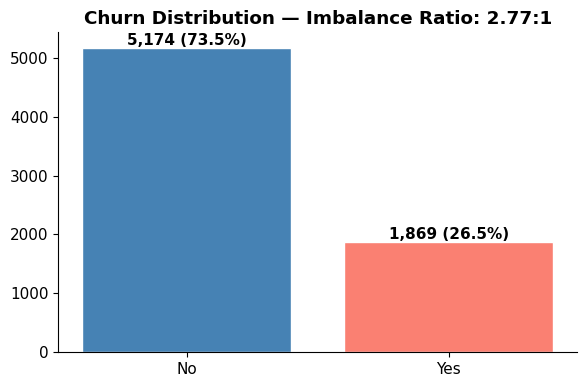

In [27]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True)
ratio = churn_counts.max() / churn_counts.min()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    churn_counts.index,
    churn_counts.values,
    color=["steelblue", "salmon"],
    edgecolor="white",
)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    ax.text(i, v + 50, f"{v:,} ({p:.1%})", ha="center", fontweight="bold")
ax.set_title(f"Churn Distribution — Imbalance Ratio: {ratio:.2f}:1", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/nb_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Churn Rate per Kategori

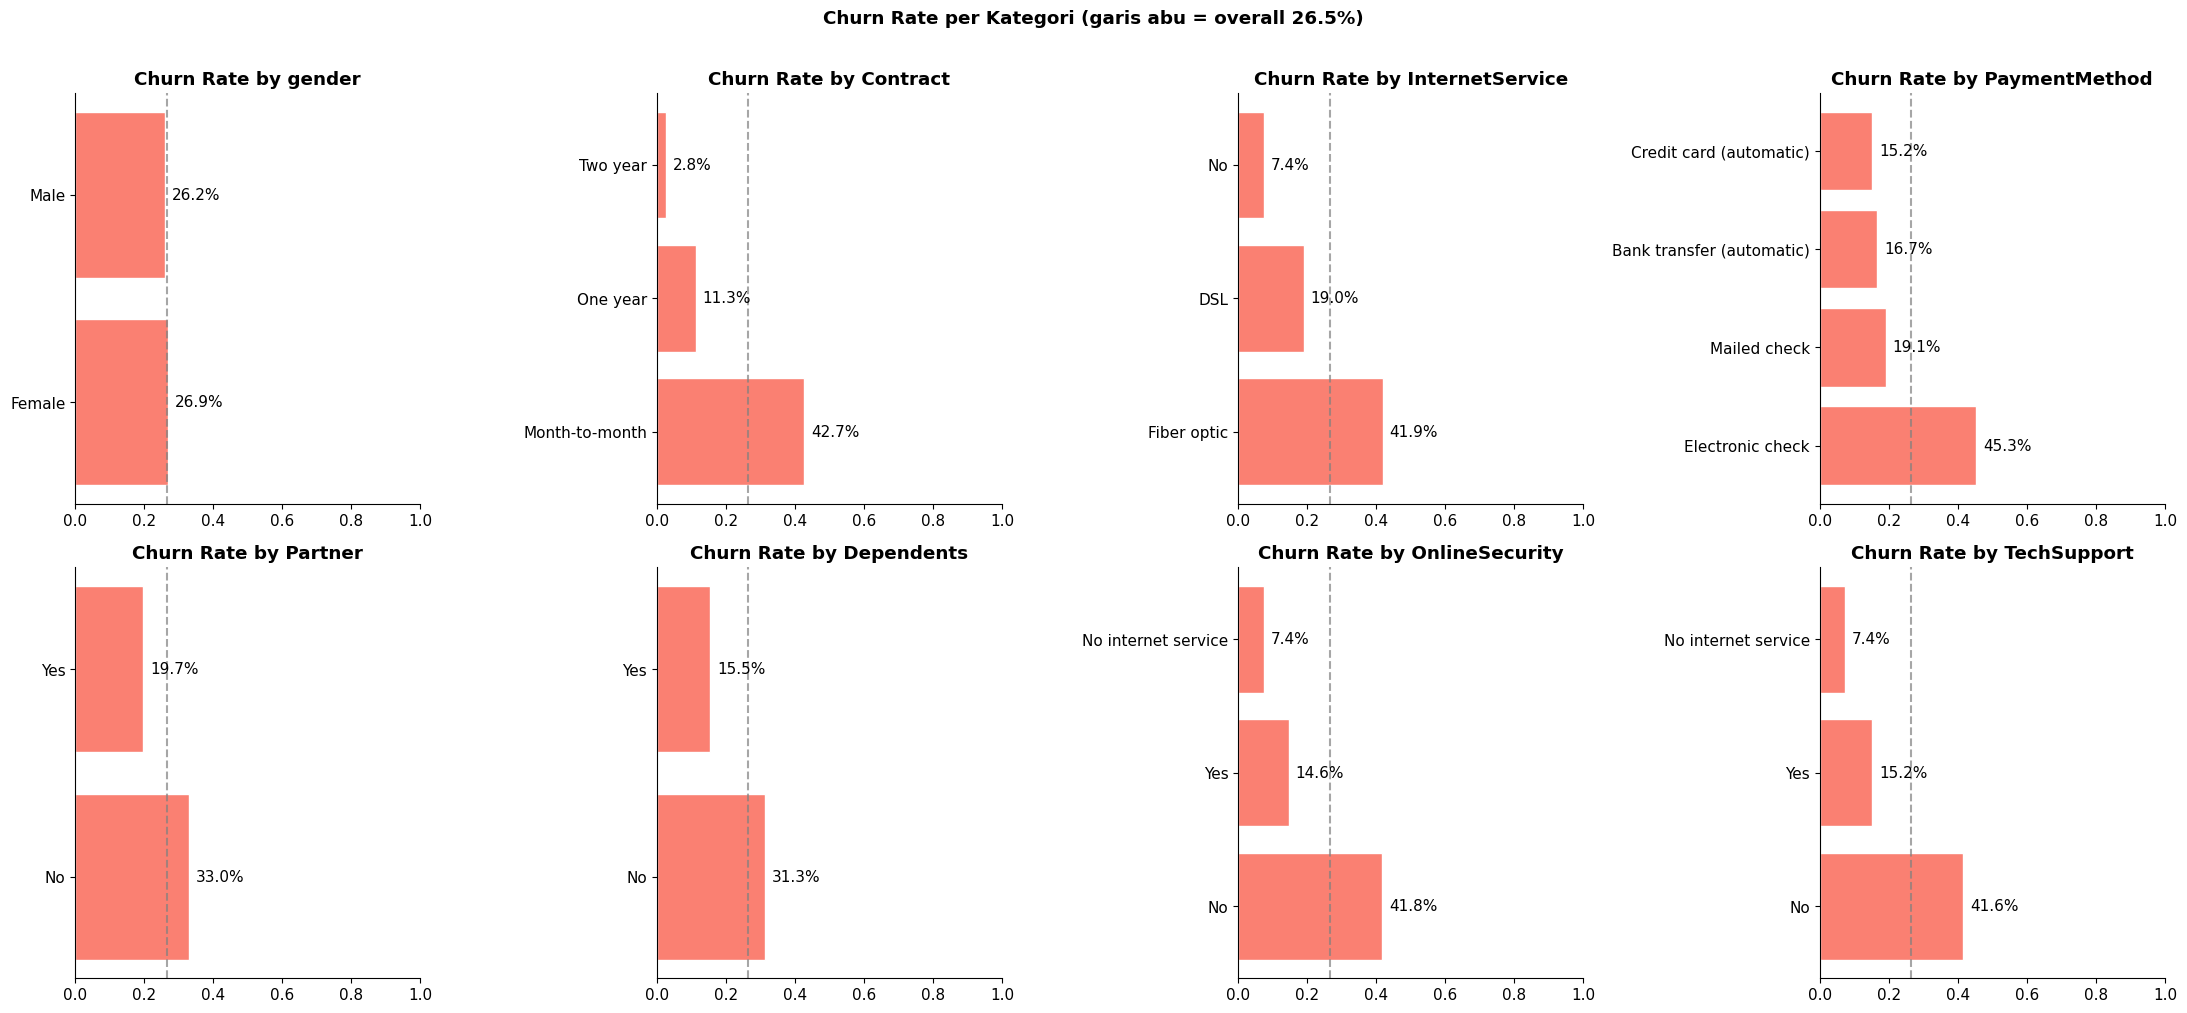

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
overall = (df["Churn"] == "Yes").mean()
for ax, col in zip(axes.ravel(), key_cats):
    cr = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )
    bars = ax.barh(cr.index, cr.values, color="salmon", edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_title(f"Churn Rate by {col}", fontweight="bold")
    for bar, v in zip(bars, cr.values):
        ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2, f"{v:.1%}", va="center")
    ax.axvline(overall, color="gray", ls="--", alpha=0.7)
plt.suptitle(
    f"Churn Rate per Kategori (garis abu = overall {overall:.1%})",
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("figures/nb_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

**Top churn drivers:** Month-to-month (~43%), Electronic check (~45%), No OnlineSecurity (~42%), Fiber optic (~42%).

### Mutual Information

$$MI(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x) \cdot p(y)}$$

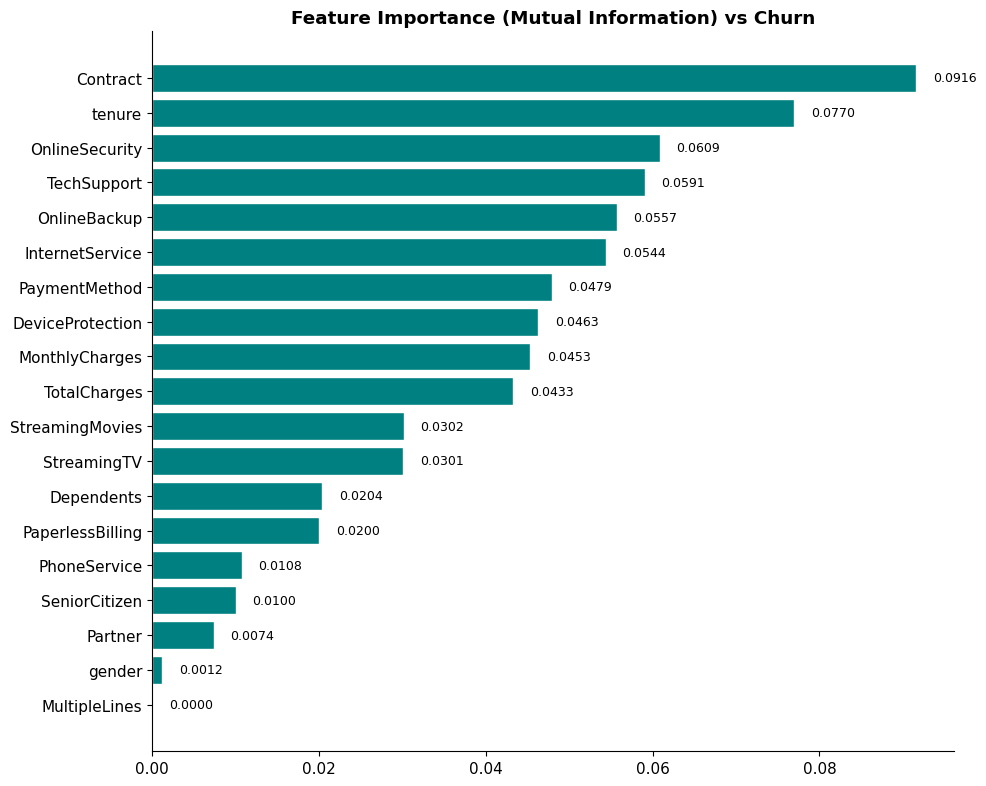

In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

df_mi = df.drop(columns=["customerID"]).copy()
le = LabelEncoder()
for col in df_mi.select_dtypes(include="object").columns:
    df_mi[col] = le.fit_transform(df_mi[col])

mi_scores = mutual_info_classif(
    df_mi.drop(columns="Churn"), df_mi["Churn"], random_state=42
)
mi_df = pd.DataFrame(
    {"Feature": df_mi.drop(columns="Churn").columns, "MI": mi_scores}
).sort_values("MI", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(mi_df["Feature"], mi_df["MI"], color="teal", edgecolor="white")
for i, (_, row) in enumerate(mi_df.iterrows()):
    ax.text(row["MI"] + 0.002, i, f"{row['MI']:.4f}", va="center", fontsize=9)
ax.set_title("Feature Importance (Mutual Information) vs Churn", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/nb_mutual_information.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** `Contract`, `tenure`, `OnlineSecurity` top features — konsisten dengan bivariate.

## 12. Simpson's Paradox

In [30]:
overall_gender = df.groupby("gender")["Churn"].apply(
    lambda x: (x == "Yes").mean()
)  # Overall churn by gender
display(overall_gender)
print(
    f"Difference: {abs(overall_gender['Male'] - overall_gender['Female']):.4f} — hampir tidak ada.\n"
)

stratified = (  # Stratified by Contract
    df.groupby(["Contract", "gender"])["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .unstack()
)
display(stratified.round(4))

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

Difference: 0.0076 — hampir tidak ada.



gender,Female,Male
Contract,,
Month-to-month,0.4374,0.4169
One year,0.1045,0.1205
Two year,0.0260,0.0306


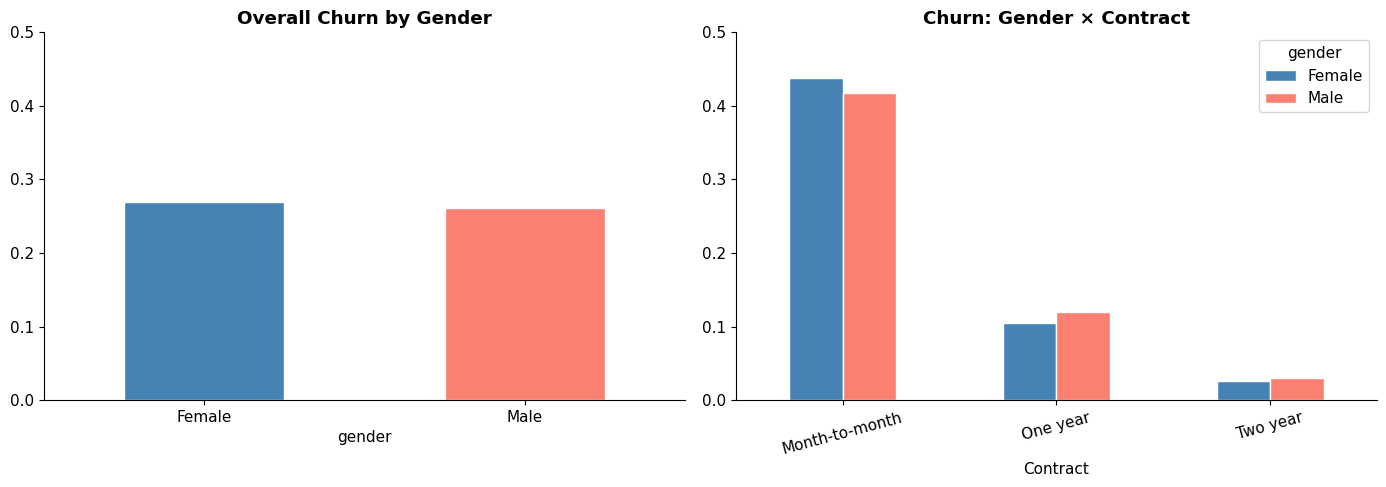

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overall_gender.plot(
    kind="bar", ax=axes[0], color=["steelblue", "salmon"], edgecolor="white"
)
axes[0].set_title("Overall Churn by Gender", fontweight="bold")
axes[0].set_ylim(0, 0.5)
axes[0].tick_params(axis="x", rotation=0)

stratified.plot(
    kind="bar", ax=axes[1], color=["steelblue", "salmon"], edgecolor="white"
)
axes[1].set_title("Churn: Gender × Contract", fontweight="bold")
axes[1].set_ylim(0, 0.5)
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("figures/nb_simpsons_demo.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretasi:** Selalu `groupby` subgrup relevan. Data agregat bisa menyesatkan.

## 13. Data Leakage

In [32]:
df["TC_est"] = (
    df["tenure"] * df["MonthlyCharges"]
)  # TotalCharges ≈ tenure × MonthlyCharges?
print(
    f"TotalCharges vs (tenure × MonthlyCharges): r = {df['TotalCharges'].corr(df['TC_est']):.3f}"
)
print("→ Hampir identik — TotalCharges redundan.")
df.drop(columns=["TC_est"], inplace=True)

TotalCharges vs (tenure × MonthlyCharges): r = 1.000
→ Hampir identik — TotalCharges redundan.


### Train-Test Contamination Demo

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["tenure", "MonthlyCharges", "TotalCharges"]].values
y = (df["Churn"] == "Yes").astype(int).values

# ❌ SALAH: scaling sebelum split
scaler_bad = StandardScaler()
X_scaled = scaler_bad.fit_transform(X)
X_tr_bad, X_te_bad, _, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ✅ BENAR: split dulu, baru scaling
X_tr, X_te, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_good = StandardScaler()
X_tr = scaler_good.fit_transform(X_tr)
X_te = scaler_good.transform(X_te)

print(f"❌ SALAH — Test mean: {X_te_bad.mean(axis=0).round(4)}  ← mendekati 0, bocor!")
print(
    f"✅ BENAR — Test mean: {X_te.mean(axis=0).round(4)}  ← ≠ 0, expected di real world"
)

❌ SALAH — Test mean: [-0.0003 -0.0136 -0.013 ]  ← mendekati 0, bocor!
✅ BENAR — Test mean: [-0.0004 -0.017  -0.0162]  ← ≠ 0, expected di real world


## Recap

| Metric | Formula |
|--------|---------|
| IQR | $Q_3 - Q_1$ |
| Z-score | $(x - \bar{x}) / s$ |
| Modified Z | $0.6745(x - \tilde{x}) / MAD$ |
| Pearson | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}}$ |
| Cramér's V | $\sqrt{\chi^2 / (n \cdot \min(r-1, c-1))}$ |
| Mutual Info | $\sum p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$ |

In [ ]:
print(f"Done — {len(df):,} rows, {df.shape[1] - 1} features, Churn {(df['Churn'] == 'Yes').mean():.1%} positive")

Done — 7,043 rows, 20 features, Churn 26.5% positive
